In [ ]:
pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of xformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.5/294.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.5/31.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 MB 14.9

In [ ]:
import wandb

wandb.login()
run = wandb.init(
    project='Fine-tune-phi on Medical COT Dataset',
    job_type="training",
    anonymous="allow"
)

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rishimanjotsingh (rishimanjotsingh-stevens-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
from unsloth import FastLanguageModel
from google.colab import userdata

# Disable compile globally
import torch
torch._dynamo.disable()



max_seq_length = 2048
dtype = None
load_in_4bit = True


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Phi-3-mini-4k-instruct",
    #model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    token = userdata.get('HF_TOKEN')
)

==((====))==  Unsloth 2025.6.12: Fast Mistral patching. Transformers: 4.53.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>{}"""

In [ ]:
question = "A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings, what would cystometry most likely reveal about her residual volume and detrusor contractions?"

FastLanguageModel.for_inference(model)
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=1200,
    use_cache=True,
)
response = tokenizer.batch_decode(outputs)
print(response[0].split("### Response:")[1])

LlamaForCausalLM has no `_prepare_4d_causal_attention_mask_with_cache_position` method defined in its base modeling class. Compiled forward passes will be sub-optimal. If you're writing code, see Llama for an example implementation. If you're a user, please report this issue on GitHub.



<think>
Okay, so I've got this medical question here about a 61-year-old woman with a history of involuntary urine loss when she coughs or sneezes, but she doesn't leak at night. She's had a gynecological exam and a Q-tip test, and I need to figure out what cystometry would show regarding her residual volume and detrusor contractions.

First, I should break down the information given. She's experiencing urinary incontinence during activities that involve coughing or sneezing, which are common triggers for stress urinary incontinence (SUI). SUI typically occurs due to the urethral sphincter not closing properly during these activities, often because of weakened pelvic floor muscles or urethral issues.

She doesn't have leakage at night, which suggests that she doesn't have nocturnal enuresis, so the problem is more likely related to SUI rather than something like overactive bladder (OAB), which often affects nighttime as well.

The gynecological exam probably included a physical examin

In [ ]:
train_prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>
{}
</think>
{}"""

In [ ]:
EOS_TOKEN = tokenizer.eos_token  # Must add EOS_TOKEN


def formatting_prompts_func(examples):
    inputs = examples["Question"]
    cots = examples["Complex_CoT"]
    outputs = examples["Response"]
    texts = []
    for input, cot, output in zip(inputs, cots, outputs):
        text = train_prompt_style.format(input, cot, output) + EOS_TOKEN
        texts.append(text)
    return {
        "text": texts,
    }

In [ ]:
#from datasets import load_dataset
#dataset = load_dataset("FreedomIntelligence/medical-o1-reasoning-SFT","en", split = "train[0:500]",trust_remote_code=True)
#dataset = dataset.map(formatting_prompts_func, batched = True,)
#dataset["text"][0]

README.md: 0.00B [00:00, ?B/s]

medical_o1_sft.json:   0%|          | 0.00/58.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19704 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

"Below is an instruction that describes a task, paired with an input that provides further context. \nWrite a response that appropriately completes the request. \nBefore answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.\n\n### Instruction:\nYou are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning. \nPlease answer the following medical question. \n\n### Question:\nGiven the symptoms of sudden weakness in the left arm and leg, recent long-distance travel, and the presence of swollen and tender right lower leg, what specific cardiac abnormality is most likely to be found upon further evaluation that could explain these findings?\n\n### Response:\n<think>\nOkay, let's see what's going on here. We've got sudden weakness in the person's left arm and leg - and that screams something neuro-related, maybe a stroke?\n\nBut wait, there's more. The right lower leg i

In [ ]:
from datasets import load_dataset
from datasets import DatasetDict

# Load a larger portion of the dataset (e.g., 5000 examples)
dataset = load_dataset(
    "FreedomIntelligence/medical-o1-reasoning-SFT",
    "en",
    split="train[:500]",
    trust_remote_code=True
)

# Format using your custom function
dataset = dataset.map(formatting_prompts_func, batched=True)

# Split into training (90%) and testing (10%) sets
split_dataset = dataset.train_test_split(test_size=0.1, seed=42)

# Access train and test sets
train_dataset = split_dataset['train']
test_dataset = split_dataset['test']

# Example output
print("Train sample:", train_dataset["text"][0])
print("Test sample:", test_dataset["text"][0])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train sample: Below is an instruction that describes a task, paired with an input that provides further context. 
Write a response that appropriately completes the request. 
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning. 
Please answer the following medical question. 

### Question:
A 4-year-old child presents with symptoms including hoarseness, a croupy cough, aphonia, dyspnea, and wheezing. Considering these symptoms, what is the most probable diagnosis?

### Response:
<think>
Alright, let's see what we have here. A 4-year-old kid showing up with that rough, bark-like cough and hoarseness? That definitely rings a bell for croup, doesn't it? Ah, croup is so common at this age, especially if it's fall or winter when those viruses love to spread.

But wait, there's more 

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # True or "unsloth" for very long context
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        # Use num_train_epochs = 1, warmup_ratio for full training runs!
        warmup_steps=5,
        max_steps=60,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/450 [00:00<?, ? examples/s]

In [ ]:
dataset

Dataset({
    features: ['Question', 'Complex_CoT', 'Response', 'text'],
    num_rows: 500
})

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 2 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,884,416 of 2,039,024,640 (1.47% trained)


Step,Training Loss
10,1.354900
20,1.078100
30,1.016400
40,1.009900
50,1.019300
60,0.989300


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


In [ ]:
question = "A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings, what would cystometry most likely reveal about her residual volume and detrusor contractions?"


FastLanguageModel.for_inference(model)  # Unsloth has 2x faster inference!
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=1200,
    use_cache=True,
)
response = tokenizer.batch_decode(outputs)
print(response[0].split("### Response:")[1])


MistralForCausalLM has no `_prepare_4d_causal_attention_mask_with_cache_position` method defined in its base modeling class. Compiled forward passes will be sub-optimal. If you're writing code, see Llama for an example implementation. If you're a user, please report this issue on GitHub.



<think>
Alright, let's think about this. We have a 61-year-old woman who's been dealing with involuntary urine loss during activities like coughing or sneezing. That sounds like stress incontinence, right? It's when the bladder can't handle the pressure from these activities.

Now, she doesn't leak at night, which is good. That means her bladder is holding up during sleep. But what about the Q-tip test? That's a way to check for hypertonic bladder syndrome, where the bladder muscle is too tense. If the Q-tip test is negative, it means her bladder isn't too tense.

So, what does that tell us about her cystometry results? Well, if her bladder isn't too tense, it's likely that her detrusor muscle isn't overly contracted. That means the cystometry would show normal detrusor contractions.

But what about the residual volume? If she's not leaking at night, it's likely that her bladder is emptying well during sleep. So, the cystometry should show a normal residual volume, which means the bla

In [ ]:
test_dataset

Dataset({
    features: ['Question', 'Complex_CoT', 'Response', 'text'],
    num_rows: 50
})

In [ ]:
def generate_response(question):
    prompt = prompt_style.format(question, "")  # Your prompt formatting template
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_new_tokens=1200,
        use_cache=True,
    )

    response = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # Extract the actual response text after the prompt
    return response.split("### Response:")[-1].strip()


In [ ]:
test_dataset = test_dataset.select(range(10))

In [ ]:
test_dataset

Dataset({
    features: ['Question', 'Complex_CoT', 'Response', 'text'],
    num_rows: 10
})

In [ ]:
# -----------------------------
# Collect Predictions & References
# -----------------------------
from tqdm import tqdm

preds = []
refs = []

for example in tqdm(test_dataset):
    question = example["Question"]
    reference = example["Response"]
    response = generate_response(question)
    preds.append(response)
    refs.append(reference)

100%|██████████| 10/10 [06:23<00:00, 38.38s/it]


In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [ ]:
pip install rouge_score

  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=2c04a48fa895b080ccdf0ff5c076a08849d3034f06f00f2f80d484431e6aa7f7
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


BLEU: 0.05844557264944228
ROUGE-1: 0.24628308324536122
ROUGE-2: 0.1171230953841513
ROUGE-L: 0.16572705076345362


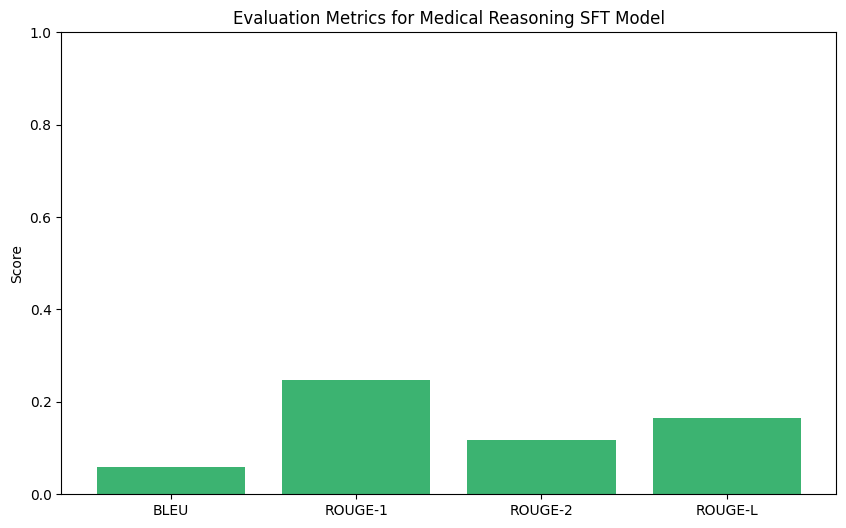

In [ ]:
import evaluate
import matplotlib.pyplot as plt

# -----------------------------
# Evaluation
# -----------------------------
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

bleu_score = bleu.compute(predictions=preds, references=[[r] for r in refs])
rouge_score = rouge.compute(predictions=preds, references=refs)

print("BLEU:", bleu_score["bleu"])
print("ROUGE-1:", rouge_score["rouge1"])
print("ROUGE-2:", rouge_score["rouge2"])
print("ROUGE-L:", rouge_score["rougeL"])

# -----------------------------
# Visualization
# -----------------------------
metrics = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores = [
    bleu_score['bleu'],
    rouge_score['rouge1'],
    rouge_score['rouge2'],
    rouge_score['rougeL']
]

plt.figure(figsize=(10, 6))
plt.bar(metrics, scores, color='mediumseagreen')
plt.title('Evaluation Metrics for Medical Reasoning SFT Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

In [ ]:
pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
from evaluate import load
bertscore = load("bertscore")

results = bertscore.compute(predictions=preds, references=refs, lang="en")

# Print mean scores
print(f"✅ BERTScore F1:      {sum(results['f1']) / len(results['f1']):.3f}")
print(f"🧠 BERTScore Precision: {sum(results['precision']) / len(results['precision']):.3f}")
print(f"📥 BERTScore Recall:    {sum(results['recall']) / len(results['recall']):.3f}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERTScore F1:      0.853
🧠 BERTScore Precision: 0.828
📥 BERTScore Recall:    0.879
